### Load Library

In [1]:

import numpy as np
import os
import glob
from collections import defaultdict
import re
from datetime import datetime
from scipy.io import loadmat
import h5py
from scipy.ndimage import convolve
from skimage import io, color, img_as_float
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt
import random
import csv
from sklearn.model_selection import train_test_split

# from ultralytics import YOLO

root_folder = "./Aeschna_isoceles/"
root_folder1 = "./Apocordulia_macrops/"
root_folder2 = "./Hemicordulia_tau/"
image_fields = [
    "imagesS0",
    "imagesS1",
    "imagesS2",
    "imagesS3",
    "imagesS4",
]



## Phase 1: Identify the bounding box for the 

### 1.1 Extract image data
#### 1.1.1 Purpose
Each file will have 5 images: imagesS0...imagesS4 (imagesSn in short). Within each imagesSn, there will be i1 and i2 (they are different exposure)

If we do the math, one data point will generate 10 images

For this reason, I will need a map to hold every image information of each file to facilitate searching as well as to hold additional data relating to an image.

#### 1.1.2 How it will be done?
By using ***python dictionary***, I will organize the data point by name -> imagesSn -> i1/i2/groundTruth-> 

Each pair has `i1` and `i2` corresponding to image1 and image2

**Note:** Whether is it i1 or i2, we only have 1 groundTruth. They are exactly the same image, just different exposure

#### 1.1.3 Result description (after extracting)
After extraction, store in `img_original_name` dict

The dictionary has 3 level with the following structure:
[original_file_name][imagesSn][data]

For example:
[20250624_115709_azimuth_000000_elevation_000000_site_1.npy]

[imageS0, ..., imagesS4]

[i1, i2, groundTruth]

In [2]:



def extract_images_from_mat_struct(data, imageSn):
    """Classic MATLAB ≤ v7.2: dict from scipy.io.loadmat."""
    imdat = data["imdat"]
    I1 = imdat[imageSn][0][0]["presetcapture"][0][0]["image"][0][0]
    I2 = imdat[imageSn][0][0]["presetcapture"][0][0]["image"][0][1]
    return I1, I2


def extract_images_from_h5(f, imageSn):
    """
    MATLAB v7.3 HDF5 `.mat`. ``f`` is ``h5py.File`` opened for reading.

    Same logical path as classic MAT: imdat → imagesSn → presetcapture → image (two frames).
    """
    target = f["imdat"][imageSn]
    pc = target["presetcapture"]

    if isinstance(pc, h5py.Group):
        preset_obj = pc
    elif isinstance(pc, h5py.Dataset):
        try:
            preset_obj = f[pc[0, 0]]
        except (TypeError, KeyError, IndexError, ValueError):
            ref0 = np.ravel(np.asarray(pc[()]))[0]
            preset_obj = f[ref0]
    else:
        return None, None

    imgs = preset_obj["image"]

    def load_ref(tok):
        tok = np.asarray(tok).flat[0]
        if isinstance(tok, h5py.Reference):
            return np.asarray(f[tok][:]).T
        return None

    if isinstance(imgs, h5py.Dataset) and h5py.check_dtype(ref=imgs.dtype) is not None:
        for ij1, ij2 in (((0, 0), (1, 0)), ((0, 0), (0, 1))):
            try:
                I1 = load_ref(imgs[ij1])
                I2 = load_ref(imgs[ij2])
            except (IndexError, TypeError):
                continue
            if I1 is not None and I2 is not None:
                return I1, I2
    elif isinstance(imgs, h5py.Dataset):
        arr = np.asarray(imgs[:])
        if arr.ndim == 3 and arr.shape[2] >= 2:
            return arr[:, :, 0].T, arr[:, :, 1].T

    return None, None


def process_all_mat_files(root_folder):
    """
    Walk ``.mat`` files; use h5py for MATLAB v7.3 (HDF5) and scipy.loadmat for older MAT.
    """
    image_original_name = {}
    cnt_entry = 0
    os.makedirs("./img", exist_ok=True)

    for subdir, parent_dir, files in os.walk(root_folder):
        for file in files:
            if not file.endswith(".mat"):
                continue
            filepath = os.path.join(subdir, file)
            if file not in image_original_name:
                image_original_name[file] = {}

            if h5py.is_hdf5(filepath):
                try:
                    with h5py.File(filepath, "r") as hf:
                        for imageSn in image_fields:
                            try:
                                I1, I2 = extract_images_from_h5(hf, imageSn)
                                if I1 is None or I2 is None:
                                    continue
                                image_original_name[file][imageSn] = {
                                    "i1": I1,
                                    "i2": I2,
                                }
                                cnt_entry += 2
                            except Exception as e:
                                print(f"Failed to extract {imageSn} in {file}: {e}")
                except Exception as e:
                    print(f"Failed to open HDF5 {file}: {e}")
                continue

            try:
                data = loadmat(filepath, struct_as_record=True)
            except NotImplementedError:
                print(f"Could not read (not HDF5 and not classic MAT): {file}")
                continue
            except Exception as e:
                print(f"Failed loadmat {file}: {e}")
                continue

            for imageSn in image_fields:
                try:
                    I1, I2 = extract_images_from_mat_struct(data, imageSn)
                    image_original_name[file][imageSn] = {
                        "i1": I1,
                        "i2": I2,
                    }
                    cnt_entry += 2
                except Exception as e:
                    print(f"Failed to extract {imageSn} in {file}: {e}")

    print(f"✅ Processed {cnt_entry} entries")
    return image_original_name, cnt_entry




Now we run the extraction 

In [3]:
image_original_name, cnt_entry = process_all_mat_files(root_folder)
print(len(image_original_name))
#20250624_120938


✅ Processed 830 entries
83


In [4]:
specific_file = "20260128_011414_azimuth_000039_elevation_000-36_site_1.mat"
print(image_original_name[specific_file]["imagesS0"]["groundTruth"])

KeyError: '20260128_011414_azimuth_000039_elevation_000-36_site_1.mat'

In [7]:
#Check if the image is correct
from typing import Any


random_file = random.choice(list[Any](image_original_name.keys()))
print(random_file)
print(image_original_name[random_file]["imagesS3"])

20250624_140857_azimuth_000060_elevation_000-30_site_1.mat
{'i1': array([[4094, 4094, 4094, ..., 2046, 2316, 2078],
       [4094, 4094, 4094, ..., 2035, 2411, 2124],
       [4094, 4094, 4094, ..., 2059, 2116, 2171],
       ...,
       [4094, 4094, 4094, ..., 2493, 2716, 2516],
       [4094, 4094, 4094, ..., 2727, 2872, 2467],
       [4094, 4094, 4094, ..., 2725, 2573, 2724]], dtype=uint16), 'i2': array([[4094, 4094, 4094, ..., 2261, 2263, 2271],
       [4094, 4094, 4094, ..., 2217, 2277, 2235],
       [4094, 4094, 4094, ..., 2273, 2239, 2270],
       ...,
       [4094, 4094, 4094, ..., 2901, 3036, 2925],
       [4094, 4094, 4094, ..., 2885, 2943, 2894],
       [4094, 4094, 4094, ..., 2940, 2945, 3019]], dtype=uint16)}


### 1.2 Set ground truth to each image in the dict

#### 1.2.1 The background of this step
The women from the lab (Mrs. Skeen) composed the groundTruth .xlxs file that we must convert to csv to store at which location the pseudopupil center supposed to detect by the model

#### 1.2.2 Disclaimer
In the first phase, this step is not necessary as we have not got the keypoint yet. But it will be helpful in the second phase



In [8]:
groundTruth_count = 0
with open('./Aeschna_isoceles_groundTruth.csv', mode ='r', encoding='utf-8-sig')as file:
  
  column_names = {}
  index_of_column = 0
  csvFile = csv.reader(file, skipinitialspace=True)
    
    # This fetches and prints the first row (usually the header)
  first_line = next(csvFile)
  for col in first_line:
    column_names[col] = index_of_column
    index_of_column += 1
  
  file_name_index = column_names['filename']
  # imagesSn_index = column_names['imagesSn']
  compare_imageSn_index = column_names['comparison image SX']
  S0x_index = column_names['S0 pseudopupil x location']
  S0y_index = column_names['S0 pseudopupil y location']
  SXx_index = column_names['SX pseudopupil x location']
  SXy_index = column_names['SX pseudopupil y location']
  ###
  next(csvFile, None)
  for lines in csvFile:
      try:
        file_name = lines[file_name_index]
        imagesSn = lines[compare_imageSn_index]
        
        imagesS0_x = lines[S0x_index]
        imagesS0_y = lines[S0y_index]
        imagesSn_x = lines[SXx_index]
        imagesSn_y = lines[SXy_index]
        #S0

        if image_original_name[file_name]["imagesS0"].get("groundTruth") is None:
          image_original_name[file_name]["imagesS0"]["groundTruth"] = [imagesS0_x, imagesS0_y]
        #Sn
        

        if not imagesSn.startswith("S"):
          imageSn_entry ="images" + "S" + str(imagesSn)
        else: 
          imageSn_entry = "images" + str(imagesSn)
      
        if imageSn_entry not in image_original_name[file_name]:
          image_original_name[file_name][imageSn_entry] = {}
          
          if image_original_name[file_name][imageSn_entry]["i1"] is None:
            raise Exception("i1 is None")
          if image_original_name[file_name][imageSn_entry]["i2"] is None:
            raise Exception("i2 is None")

        image_original_name[file_name][imageSn_entry]["groundTruth"] = [imagesSn_x, imagesSn_y]
        # entry = {
        #       "mat_file": f"{subdir}/{item}",
        #       "angle": imageSn,
        #       "cx": x,
        #       "cy": y
        #   }
          #set to {} to store groundTruth later 
        groundTruth_count += 1
      except Exception as e:
        print(f"[ERROR] Failed to process line : {e}")
    # Always assign or check groundTruth for Sn
print(f"{groundTruth_count} labels are counted in groung truth file")
# if groundTruth_count != len(cnt_entry):
#   print(f"[WARNING] Ground truth count ({groundTruth_count}) DOES NOT match the total entries ({cnt_entry}). There may be imagesSn without ground truth")
               

279 labels are counted in groung truth file


In [146]:
### code 

import json

# Initialize the list
labels_data = []

for item in list(image_original_name.keys()):
    # Extract azimuth and define the subdirectory
    # e.g., if item is "file_a_b_0_c", nAzimuth becomes "0"
    nAzimuth = item.split("_")[3]
    subdir = str(int(nAzimuth)) + "Azimuth"

    for (imageSn, data) in image_original_name[item].items():
     
        
        try:
          x, y = data['groundTruth']
          # Build the dictionary for this entry
          entry = {
              "mat_file": f"{subdir}/{item}",
              "angle": imageSn,
              "cx": x,
              "cy": y
          }
        except Exception as e:
          continue
        
        labels_data.append(entry)

# Write the list to labels.json
with open('labels.json', 'w') as f:
    json.dump(labels_data, f, indent=4)

print("Successfully saved to labels.json")


Successfully saved to labels.json


### 1.2.3 Convert .mat file to .png

Up until now, we have only had .mat files, which are difficult to visualize. In this step, we convert those .mat files into .png format. 

To ensure consistency with our ground truth data, we are only converting files that have corresponding ground truth information; the remaining files will be reserved for the testing purpose if needed.

In [61]:
def repair_image(data, threshold=60000):
    # 1. Create a map of the local averages for the entire 560x960 grid
    # The 'size=3' creates a 3x3 moving window
    local_averages = uniform_filter(data.astype(float), size=3)
    
    # 2. Create a boolean mask of where the hot pixels are
    hot_pixel_mask = data > threshold
    
    # 3. Replace only the 'True' positions in the mask with the averages
    # np.where(condition, value_if_true, value_if_false)
    fixed_image = np.where(hot_pixel_mask, local_averages, data)
    
    return fixed_image.astype(data.dtype)

def brighten_dark_pixels(img, dark_thresh=4000, boost=3000):
        """Pixels below ``dark_thresh`` get ``boost`` added; uses a copy, clips integer dtypes."""
        if img is None:
            raise ValueError("image array is None")
        arr = np.asarray(img)
        if arr.dtype == object:
            arr = np.asarray(arr.tolist())
        if np.issubdtype(arr.dtype, np.integer):
            out = np.asarray(arr, dtype=np.int64, copy=True)
            out[out < dark_thresh] += boost
            ii = np.iinfo(arr.dtype)
            out = np.clip(out, ii.min, ii.max).astype(arr.dtype)
        else:
            out = np.array(arr, dtype=np.float64, copy=True)
            out[out < dark_thresh] += boost
            out = out.astype(arr.dtype, copy=False)
        return out


def process_matrix(matrix):
    matrix = repair_image(matrix)
    return brighten_dark_pixels(matrix)
    
# Usage:
# cleaned_matrix = repair_image(your_input_matrix)

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


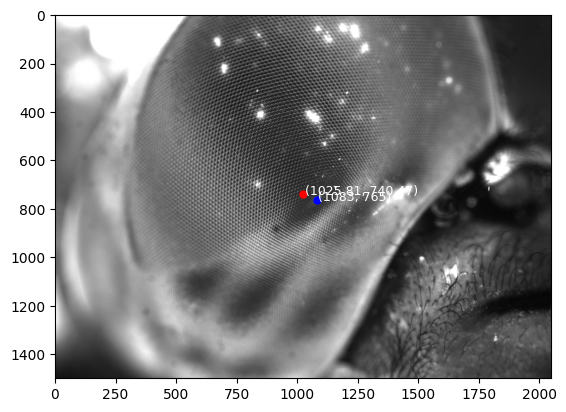

In [ ]:
#36,20250624_134117_azimuth_000036_elevation_000-30_site_1.mat,1025.81,740.47,0.7496,5,5


# 1. Access the image data
img = image_original_name['20260128_012124_azimuth_000039_elevation_000-54_site_1.mat']['imagesS0']['i1']

# 2. Define your coordinates
# Note: Matplotlib uses (x, y) which corresponds to (column, row)
x_coord, y_coord = 1025.81,740.47


x_truth, y_truth = 1128.93792,765.8327681
# 3. Display the image
plt.imshow(img, cmap='gray')

# 4. Plot the point
# 'ro' creates a Red circle; markersize (ms) adjusts the size
plt.plot(x_coord, y_coord, 'ro', markersize=5) 
plt.plot(x_truth, y_truth, 'bo', markersize=5) 

# Optional: Add a label
plt.text(x_coord + 5, y_coord, f'({x_coord}, {y_coord})', color='white', fontsize=9)
plt.text(x_truth + 5, y_truth, f'({x_truth}, {y_truth})', color='white', fontsize=9)
plt.show()

# 20251010_150127_azimuth_000036_elevation_000-54_site_1.mat
# 20251010_150127_azimuth_000036_elevation_000-54_site_1.mat
# image_original_name['20260128_012350_azimuth_000039_elevation_000-72_site_1.mat']

In [ ]:


import csv

# Initialize your dictionary
data_dict = {}

# Replace 'your_file.csv' with the actual path to your file
with open('results_v2_1.csv', mode='r') as f:
    # Use DictReader to access columns by their header names
    reader = csv.DictReader(f)
    
    for row in reader:
        # Load filename as key, and [cx, cy] as a list of floats
        key = row['filename']
        value = [float(row['cx']), float(row['cy'])]
        data_dict[key] = value

# Resulting entry:
# {'20250624_121037_azimuth_000000_elevation_000-30_site_1.mat': [1010.75, 733.66]}
for key, item in image_original_name.items():
    # 1. Access the image data
    
    if not item:
        continue

    for angle in image_fields:
        ground_truth = item[angle].get("groundTruth")  # None if absent

        img = item[angle]['i1']

        x_coord, y_coord = data_dict[key][0], data_dict[key][1]

        plt.figure()
        plt.imshow(img, cmap='gray')
        plt.plot(x_coord, y_coord, 'ro', markersize=2, label='Predicted')

        if ground_truth:  # Only plot if ground truth actually exists
            x_truth, y_truth = ground_truth
            plt.plot(float(x_truth), float(y_truth), 'bo', markersize=2, label='Truth')

        plt.savefig(f"./14_05_26(1)/{key}_{angle}.png")
        plt.close()

In [ ]:

# plotting without ground truth. PURPOSE: test model on new data
import csv

# Initialize your dictionary
data_dict = {}

# Replace 'your_file.csv' with the actual path to your file
with open('results-Aeschna_isoceles.csv', mode='r') as f:
    # Use DictReader to access columns by their header names
    reader = csv.DictReader(f)
    
    for row in reader:
        # Load filename as key, and [cx, cy] as a list of floats
        key = row['filename']
        value = [float(row['cx']), float(row['cy'])]
        
        data_dict[key] = value

# Resulting entry:
# {'20250624_121037_azimuth_000000_elevation_000-30_site_1.mat': [1010.75, 733.66]}
for key, item in image_original_name.items():
    # 1. Access the image data
    if not item:
        continue
    img = item['imagesS0']['i2']
    
    # 2. Coordinates
    if not item['imagesS0'].get("groundTruth"):
        continue
    
    x_truth, y_truth = item['imagesS0']['groundTruth']

    x_coord, y_coord = data_dict[key][0], data_dict[key][1] # same for all key
    print(x_truth, y_truth, x_coord, y_coord)
    # 3. Create the plot
    plt.figure() # Create a new figure for each iteration
    plt.imshow(img, cmap='gray')
    plt.plot(x_coord, y_coord, 'ro', markersize=5, label='Predicted') 
    plt.plot(float(x_truth), float(y_truth), 'bo', markersize=5, label='Truth') 

    # 4. Save the plot (including the dots and labels)
    # Use a string for the filename, e.g., using the key from your dictionary
    plt.savefig(f"./11_05_26(2)/{key}_plotted.png")
    
    # 5. Close the plot to save memory
    plt.close()

preprocess_image() -> scan and remove salt noise -> brighten image

  

In [20]:
def save_image_with_groundTruth_to_folder(root_folder, folder_to_save):

    """
    Recursively processes all .mat files inside a root folder.
    
    Parameters
    ----------
    root_folder : str
        Path to the main directory (e.g. '/path/to/Aeschna_isoceles')
    """

    

    cnt_file = 0
    os.makedirs(folder_to_save, exist_ok=True)
    if not folder_to_save.endswith("/"):
        folder_to_save += "/"

    for subdir, parent_dir, files in os.walk(root_folder):
        print(subdir,files)
        for file in files:
            if file.endswith('.mat'):
                filepath = os.path.join(subdir, file)
                
                if file not in image_original_name:
                    image_original_name[file] = {}
                
                try:
                    for imageSn in image_fields:
                        
                        filename_only = file.split(".")[0]
                        if  image_original_name[file][imageSn].get("groundTruth") is not None:
                            # imageSn_short = imageSn.split("images")[1]
                            filename = folder_to_save + filename_only + "_" + imageSn + ".png"
                            i1_for_save = image_original_name[file][imageSn]["i1"]
                            plt.imsave(filename, i1_for_save, cmap='gray')
                            plt.close()
                            cnt_file += 1

                            # filename = folder_to_save + filename_only + "_" +imageSn + "_i2.png"
                            # i2_for_save = process_matrix(image_original_name[file][imageSn]["i2"])
                            # plt.imsave(filename, i2_for_save, cmap='gray')
                            # plt.close()
                            cnt_file += 1
                except Exception as e:
                    print(f"Failed to extract {imageSn} in {file}: {e}")
    print(f"✅ Processed {cnt_file} file")



In [13]:
def save_full_images_to_folder(root_folder, folder_to_save):

    """
    Recursively processes all .mat files inside a root folder.
    
    Parameters
    ----------
    root_folder : str
        Path to the main directory (e.g. '/path/to/Aeschna_isoceles')
    """

    

    cnt_file = 0
    os.makedirs(folder_to_save, exist_ok=True)
    if not folder_to_save.endswith("/"):
        folder_to_save += "/"

    for subdir, parent_dir, files in os.walk(root_folder):
        print(subdir,files)
        for file in files:
            if file.endswith('.mat'):
                filepath = os.path.join(subdir, file)
                
                if file not in image_original_name:
                    image_original_name[file] = {}
                
                try:
                    for imageSn in image_fields:
                        
                        filename_only = file.split(".")[0]

                        #imageSn_short = imageSn.split("images")[1]
                        filename = folder_to_save + filename_only + "_" + imageSn + ".png"
                        i1_for_save = image_original_name[file][imageSn]["i1"]
                        plt.imsave(filename, i1_for_save, cmap='gray')
                        plt.close()
                        cnt_file += 1

                        # filename = folder_to_save + filename_only + "_" +imageSn + "_i2.png"
                        # i2_for_save = process_matrix(image_original_name[file][imageSn]["i2"])
                        # plt.imsave(filename, i2_for_save, cmap='gray')
                        # plt.close()
                        cnt_file += 1
                except Exception as e:
                    print(f"Failed to extract {imageSn} in {file}: {e}")
    print(f"✅ Processed {cnt_file} file")


Execute conversion

In [21]:
folder_to_save = f"./830-images-Aeschna_isoceles"
print("start save_image_with_groundTruth_to_folder")
# save_image_with_groundTruth_to_folder(root_folder1, folder_to_save)
save_image_with_groundTruth_to_folder(root_folder, folder_to_save)

start save_image_with_groundTruth_to_folder
./Aeschna_isoceles/ []
./Aeschna_isoceles/0Azimuth ['20250624_121037_azimuth_000000_elevation_000-30_site_1.mat', '20250624_121151_azimuth_000000_elevation_000-33_site_1.mat', '20250624_121250_azimuth_000000_elevation_000-36_site_1.mat', '20250624_121359_azimuth_000000_elevation_000-39_site_1.mat', '20250624_121508_azimuth_000000_elevation_000-42_site_1.mat', '20250624_121658_azimuth_000000_elevation_000-45_site_1.mat', '20250624_121825_azimuth_000000_elevation_000-48_site_1.mat', '20250624_121950_azimuth_000000_elevation_000-48_site_1.mat', '20250624_122146_azimuth_000000_elevation_000-54_site_1.mat', '20250624_122253_azimuth_000000_elevation_000-57_site_1.mat', '20250624_122352_azimuth_000000_elevation_000-57_site_1.mat', '20250624_122517_azimuth_000000_elevation_000-60_site_1.mat', '20250624_124240_azimuth_000000_elevation_000-24_site_1.mat', '20250624_124439_azimuth_000000_elevation_000-18_site_1.mat', '20250624_124600_azimuth_000000_elev

In [17]:
folder_to_save = "./img-Apocordulia_macrops"
save_image_with_groundTruth_to_folder(root_folder1, folder_to_save)

./Apocordulia_macrops/ []
./Apocordulia_macrops/0Azimuth ['20260127_223058_azimuth_000000_elevation_000000_site_1.mat', '20260127_223215_azimuth_000000_elevation_000012_site_1.mat', '20260127_223343_azimuth_000000_elevation_000012_site_1.mat', '20260127_223507_azimuth_000000_elevation_0000-6_site_1.mat', '20260127_223610_azimuth_000000_elevation_000-12_site_1.mat', '20260127_223719_azimuth_000000_elevation_000-18_site_1.mat', '20260127_223834_azimuth_000000_elevation_000-24_site_1.mat', '20260127_223947_azimuth_000000_elevation_000-30_site_1.mat', '20260127_224058_azimuth_000000_elevation_000-36_site_1.mat', '20260127_224232_azimuth_000000_elevation_000-42_site_1.mat', '20260127_224413_azimuth_000000_elevation_000-48_site_1.mat', '20260127_224619_azimuth_000000_elevation_000-54_site_1.mat', '20260127_224741_azimuth_000000_elevation_000-60_site_1.mat', '20260127_224917_azimuth_000000_elevation_000-66_site_1.mat', '20260127_225031_azimuth_000000_elevation_000-72_site_1.mat', '20260127_22

### This section check the quality of the groundTruth file

For all the data points in ``image_original_name``, check which imagesSn that entry is missing

In [ ]:
# The list of keys we expect to find in every file entry

# Find missing entries
missing_report = {
    file_name: [s for s in image_fields if s not in sets_dict]
    for file_name, sets_dict in image_original_name.items()
    if not all(s in sets_dict for s in image_fields)
}

# Print the results
for file, missing in missing_report.items():
    print(f"File: {file} | Missing: {', '.join(missing)}")


File: 20250624_115709_azimuth_000000_elevation_000000_site_1.mat | Missing: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
File: 20250624_135251_azimuth_000048_elevation_000-30_site_1.mat | Missing: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
File: 20250624_135357_azimuth_000048_elevation_000-30_site_1.mat | Missing: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
File: 20250624_135507_azimuth_000048_elevation_000-36_site_1.mat | Missing: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
File: 20250624_135641_azimuth_000054_elevation_000-42_site_1.mat | Missing: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
File: 20250624_141620_azimuth_000072_elevation_000-24_site_1.mat | Missing: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
File: 20250624_140857_azimuth_000060_elevation_000-30_site_1.mat | Missing: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
File: 20250624_141049_azimuth_000066_elevation_000-36_site_1.mat | Missing: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4


For all the data points in ``image_original_name``, check which entry is missing ``groundTruth`` information

In [ ]:
# Dictionary to store {file_name: [list_of_missing_sessions]}
from itertools import count


missing_report = {
    file_name: 
    [session_id for session_id, data in sessions.items() if 'groundTruth' not in data]
    for file_name, sessions in image_original_name.items()
}

# Clean up: Remove files that have 0 missing sessions
missing_report = {k: v for k, v in missing_report.items() if v}

# Display the results
count_missing = 0
for file, sessions in missing_report.items():
    print(f"File: {file}")
    print(f"  └─ Missing Sessions: {', '.join(sessions)}")
    count_missing += len(sessions)
    if len(sessions) >= 4:
        print(file)
print(count_missing)

File: 20260127_235457_azimuth_000018_elevation_000000_site_1.mat
  └─ Missing Sessions: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
20260127_235457_azimuth_000018_elevation_000000_site_1.mat
File: 20260128_031319_azimuth_000018_elevation_000027_site_1.mat
  └─ Missing Sessions: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
20260128_031319_azimuth_000018_elevation_000027_site_1.mat
File: 20260127_233724_azimuth_000018_elevation_000-84_site_1.mat
  └─ Missing Sessions: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
20260127_233724_azimuth_000018_elevation_000-84_site_1.mat
File: 20260127_234301_azimuth_000018_elevation_000-60_site_1.mat
  └─ Missing Sessions: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
20260127_234301_azimuth_000018_elevation_000-60_site_1.mat
File: 20260127_235602_azimuth_000018_elevation_000006_site_1.mat
  └─ Missing Sessions: imagesS0, imagesS1, imagesS2, imagesS3, imagesS4
20260127_235602_azimuth_000018_elevation_000006_site_1.mat
File: 20260127_23511

### Labeling pseudopupil with Label Studio

In [ ]:
! conda activate ml-learning # activate any environment that contains label-studio
! label-studio --port 8081 # start label-studio server


### Parse json data from label studio

In [ ]:
import json
import os

# Create an output directory so your workspace doesn't get cluttered

class_index = 1 #only 1 class: pseudopupil. 1 is taken from config.yaml

def parse_label_studio_json(file_name, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    try:
        with open(file_name, 'r') as file:
            data = json.load(file)

        # Check if data is a list; if it's a single dict, wrap it in a list
        items = data if isinstance(data, list) else [data]
        
        for index, item in enumerate(items):
            # Define a unique filename (e.g., label_0.txt, label_1.txt)
            # Or use a key from your JSON like item['id'] if available
            img_name = item["img"]
            label_file_name = img_name.split("/img/")[1]
            file_path = os.path.join(output_dir, label_file_name)
        
            
            with open(file_path, 'w') as out_file:
                # Option A: Write as raw string representation
                data = item["kp-1"]

                st = str(class_index)
                for kp in data:
                    st += " " + str(kp["x"]) + " " + str(kp["y"]) + " " + str(kp["width"])+ " " + str(kp["height"])
                out_file.write(st)
                
                # Option B: Write as formatted JSON string (cleaner look)
                # out_file.write(json.dumps(item, indent=4))

        print(f"Successfully wrote {len(items)} files to '{output_dir}'.")

    except FileNotFoundError:
        print("Error: 'label-data.json' not found.")
    except json.JSONDecodeError:
        print("Error: Invalid JSON format.")

In [ ]:
#Parse label json file

json_file = './added-marcops-files.json'
output_dir = './label-marcops/'
parse_label_studio_json(json_file, output_dir)



KeyError: 'img'

### Split - Train - Test

Before that, we rename the labels downloaded from label studio first as labe studio prefix .txt file with a unique id. We want to get rid this the prefix to make image and label file name match together
labels/00a06863__20250624_141835_azimuth_000078_elevation_000-24_site_1_imagesS0_i1.txt
labels/20250624_141835_azimuth_000078_elevation_000-24_site_1_imagesS0_i1.txt

In [27]:
label_dir= "./added-marcops-files/labels/"

In [ ]:
for file in os.listdir(label_dir):
    print(file)
    if len(file.split("__")) == 2:
        # print(file)
        # print(os.path.join(label_dir, file.split("__")[1] ))
        os.rename(os.path.join(label_dir, file), os.path.join(label_dir, file.split("__")[1]))
    

81d3c560__20250624_130846_azimuth_000012_elevation_000-42_site_1_imagesS4_i2.txt
96f06bac__20250624_123235_azimuth_000006_elevation_000-48_site_1_imagesS0_i2.txt
0546b1a4__20250624_121151_azimuth_000000_elevation_000-33_site_1_imagesS0_i2.txt
8434c9d8__20250624_134236_azimuth_000036_elevation_000-36_site_1_imagesS0_i2.txt
0490b99b__20250624_130735_azimuth_000012_elevation_000-36_site_1_imagesS4_i1.txt
f7a6c919__20250624_135507_azimuth_000048_elevation_000-36_site_1_imagesS1_i2.txt
8c0d94bd__20250624_131412_azimuth_000012_elevation_000-60_site_1_imagesS3_i2.txt
b49abb10__20250624_141239_azimuth_000066_elevation_000-30_site_1_imagesS4_i2.txt
af393b5c__20250624_141239_azimuth_000066_elevation_000-30_site_1_imagesS1_i1.txt
43d75cff__20250624_125433_azimuth_000000_elevation_000018_site_1_imagesS4_i1.txt
8397283e__20250624_122955_azimuth_000006_elevation_000-54_site_1_imagesS2_i2.txt
69add965__20250624_135107_azimuth_000042_elevation_000-30_site_1_imagesS3_i1.txt
b671667d__20250624_131712_az

In [29]:
import os
from sklearn.model_selection import train_test_split
import shutil

# Path to your image folder
image_dir = './img'
# List all images
all_images = os.listdir(image_dir)
all_labels = [x.split('.')[0] + '.txt' for x in all_images] 
print(all_images[:10])
print(all_labels[:10])
print(f"Total images: {len(all_images)}")

# Split into train and test (80-20 split)
train_images, val_and_test_images, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=0.20, random_state=42
)

# Step 2: Split temp into 15% val and 5% test (half of val_and_test_images each)
val_images, test_images, val_labels, test_labels = train_test_split(
    val_and_test_images, temp_labels, test_size=0.25, random_state=42
)# 0.176 ≈ 15% of total dataset

# Create directories for output
for split in ['train', 'val', 'test']:
    os.makedirs(f'dataset/images/{split}', exist_ok=True)
    os.makedirs(f'dataset/labels/{split}', exist_ok=True)



# Move or copy files
for img in train_images:
    shutil.copy(os.path.join(image_dir, img), 'dataset/images/train')
for img in train_labels:
    shutil.copy(os.path.join(label_dir, img), 'dataset/labels/train')

for img in val_images:
    shutil.copy(os.path.join(image_dir, img), 'dataset/images/val')
for img in val_labels:
    shutil.copy(os.path.join(label_dir, img), 'dataset/labels/val')

for img in test_images:
    shutil.copy(os.path.join(image_dir, img), 'dataset/images/test')
for img in test_labels:
    shutil.copy(os.path.join(label_dir, img), 'dataset/labels/test')

print("✅ Split completed successfully!")


['20250624_135251_azimuth_000048_elevation_000-30_site_1_imagesS2_i1.png', '20250624_121950_azimuth_000000_elevation_000-48_site_1_imagesS1_i1.png', '20250624_124439_azimuth_000000_elevation_000-18_site_1_imagesS2_i1.png', '20250624_125856_azimuth_000006_elevation_000006_site_1_imagesS0_i2.png', '20250624_141049_azimuth_000066_elevation_000-36_site_1_imagesS3_i1.png', '20250624_121037_azimuth_000000_elevation_000-30_site_1_imagesS0_i1.png', '20250624_124240_azimuth_000000_elevation_000-24_site_1_imagesS4_i1.png', '20250624_130242_azimuth_000006_elevation_000-12_site_1_imagesS0_i1.png', '20250624_123858_azimuth_000006_elevation_000-30_site_1_imagesS2_i1.png', '20250624_130116_azimuth_000006_elevation_0000-6_site_1_imagesS0_i1.png']
['20250624_135251_azimuth_000048_elevation_000-30_site_1_imagesS2_i1.txt', '20250624_121950_azimuth_000000_elevation_000-48_site_1_imagesS1_i1.txt', '20250624_124439_azimuth_000000_elevation_000-18_site_1_imagesS2_i1.txt', '20250624_125856_azimuth_000006_elev

FileNotFoundError: [Errno 2] No such file or directory: './added-marcops-files/labels/20250624_122517_azimuth_000000_elevation_000-60_site_1_imagesS2_i1.txt'

In [ ]:
model = YOLO("yolo11m-obb.pt")  # or "yolov8n.yaml" to start from scratch
model.train(
    data="./config/dragonfly.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="runs-yolov11m-obb",
    name="exp1",
)

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.214 🚀 Python-3.10.18 torch-2.8.0 CPU (Apple M1 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./config/dragonfly.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp1, nbs=64, nms=False, opset=None, optimize=False, 

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

folder = "runs-yolov11m-obb"
test_dir = "/Users/hungluong/Downloads/Pseudopupil Project/img_macrops/"
# path to pytorch best model (best.pt)
path_to_best_model = folder + "/exp1/weights/best.pt"
model = YOLO(path_to_best_model)
results = model.predict(source=test_dir, 
    save=True,
    save_txt=True,
    project=folder,
    verbose=False,
    conf=0.005,
    max_det=1)


Results saved to /Users/hungluong/Downloads/Pseudopupil Project/runs/obb/runs-yolov11m-obb/predict
364 labels saved to /Users/hungluong/Downloads/Pseudopupil Project/runs/obb/runs-yolov11m-obb/predict/labels


In [ ]:
import os
import shutil

# Define paths
image_dir = '/Users/hungluong/Downloads/Pseudopupil Project/runs/obb/runs-yolov11m-obb/predict/'
label_dir = '/Users/hungluong/Downloads/Pseudopupil Project/runs/obb/runs-yolov11m-obb/predict/labels'
output_dir = 'to_be_labeled'

# Create output directory if it doesn't exist


# Get list of image names (without extension)
# This assumes your images are .jpg or .png
images = {os.path.splitext(f)[0] for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))}

# Get list of label names (without extension)
labels = {os.path.splitext(f)[0] for f in os.listdir(label_dir) if f.endswith('.txt')}

# Find images that are NOT in labels
missed_images = images - labels

print(f"Found {len(missed_images)} images with no detections.")

# Move or Copy them to a new folder for inspection
for img_name in missed_images:
    # Check for original extension to find the file
    for ext in ['.jpg', '.jpeg', '.png']:
        img_path = os.path.join(image_dir, img_name + ext)
        if os.path.exists(img_path):
            print(img_path)
            break

print(f"All missed images have been copied to: {output_dir}")

Found 2 images with no detections.
/Users/hungluong/Downloads/Pseudopupil Project/runs/obb/runs-yolov11m-obb/predict/20260128_011901_azimuth_000036_elevation_000-48_site_1_imagesS3_i2.jpg
/Users/hungluong/Downloads/Pseudopupil Project/runs/obb/runs-yolov11m-obb/predict/20260128_011750_azimuth_000039_elevation_000-48_site_1_imagesS0_i2.jpg
All missed images have been copied to: to_be_labeled


In [ ]:
print(results[5].obb)
# print(results[0].path)
#0 0.472701 0.563731 0.472918 0.492555 0.413746 0.492219 0.413529 0.563395


ultralytics.engine.results.OBB object with attributes:

cls: tensor([0., 0.])
conf: tensor([0.8357, 0.8238])
data: tensor([[4.3500e+02, 7.7920e+02, 1.5729e+02, 1.4669e+02, 3.3269e-03, 8.3575e-01, 0.0000e+00],
        [1.0054e+03, 7.9099e+02, 1.4745e+02, 1.4081e+02, 2.5354e-03, 8.2379e-01, 0.0000e+00]])
id: None
is_track: False
orig_shape: (1500, 2048)
shape: torch.Size([2, 7])
xywhr: tensor([[4.3500e+02, 7.7920e+02, 1.5729e+02, 1.4669e+02, 3.3269e-03],
        [1.0054e+03, 7.9099e+02, 1.4745e+02, 1.4081e+02, 2.5354e-03]])
xyxy: tensor([[ 356.1131,  705.5938,  513.8921,  852.8020],
        [ 931.5236,  720.3972, 1079.3287,  861.5836]])
xyxyxyxy: tensor([[[ 513.4041,  852.8020],
         [ 513.8921,  706.1171],
         [ 356.6011,  705.5938],
         [ 356.1131,  852.2787]],

        [[1078.9718,  861.5836],
         [1079.3287,  720.7711],
         [ 931.8806,  720.3972],
         [ 931.5236,  861.2097]]])
xyxyxyxyn: tensor([[[0.2507, 0.5685],
         [0.2509, 0.4707],
         [0.17

###

In Label Studio, create a new project with "Keypoint Labeling"
import data from `./Aeschna_isoceles/images`
Create a new task with `Image` type


In [ ]:
from cProfile import label
from os import wait3
import cv2
import torch

# Assuming your coordinates are stored in a list like this:
# coords = [("123,45", "678,90"), ("234,56", "789,01"), ...]
# /Users/hungluong/Downloads/Pseudopupil Project/runs-yolov11m-obb/predict/_imagesS1_i2.jpg

# tasks = [
#     ("20250624_123706_azimuth_000006_elevation_000-36_site_1.txt", "imagesS1")
# ]

def getFilenameImageSnI1orI1(concated_filename):
    file = concated_filename.split(".")[0] # 20250624_121037_azimuth_000000_elevation_000-30_site_1_imagesS2_i2
    filename = file.split("_")[0:len(file.split("_"))-2] #split by "_" and remove the last 2 elements
    filename = "_".join(filename) #join the list into a string
    imageSn = file.split("_")[-2]   #get the last element of the split list
    i1_or_i2 = file.split("_")[-1]
    return filename, imageSn, i1_or_i2


label_dir = "/Users/hungluong/Downloads/Pseudopupil Project/runs-yolov11m-obb/predict/labels/"
label_files = os.listdir(label_dir)
tasks = []
coords_list_dict = {}
for label_file in label_files:
    if not label_file.endswith(".txt"):
        continue
    #20250624_121037_azimuth_000000_elevation_000-30_site_1_imagesS2_i2.txt
    file = label_file.split(".")[0] # 20250624_121037_azimuth_000000_elevation_000-30_site_1_imagesS2_i2
    
    filename, imageSn, i1_or_i2 = getFilenameImageSnI1orI1(file)
    
    
    tasks.append((filename, imageSn, i1_or_i2))

    with open(os.path.join(label_dir, label_file), "r") as f:
        lines = f.readlines()
    for line in lines:
        if line.strip() == "":
            continue
        parts = line.strip().split(" ")
        _, x1, y1, x2, y2, x3, y3, x4, y4 = parts
        coords_list = [x1, y1, x2, y2, x3, y3, x4, y4]
        coords_list_dict[(filename, imageSn, i1_or_i2)] = coords_list

# for (filename, imageSn) in tasks:
#     if not imageSn:
#         continue
        
#     file = filename.split(".")[0]
#     s = imageSn
#     img_path = './img/' + file + '_' + s + '_i2.png'
#     img = cv2.imread(img_path)
    
#     if img is None:
#         print(f"Skipping: {img_path} not found.")
#         continue

#     print(results[5].path)
#     print(img_path)

#     # Get your list of 4 groundTruth coordinates
#     # Adjust this line if your data structure stores the 4 points differently
#     coords_list = torch.tensor(results[5].obb.xyxyxyxy)
#     # xyxyxyxy.cpu().detach().numpy().flatten().tolist()
#     cooods_list = coords_list.cpu().detach().numpy().flatten().tolist()

#     all_boxes = results[5].obb.xyxyxyxy 

#     # 2. Get the class IDs and confidence (if you need them for save_txt)
#     classes = results[5].obb.cls.cpu().numpy()
#     confidences = results[5].obb.conf.cpu().numpy()

#     # print(float(coords_list[0]))
#     # Get image dimensions (height, width)
#     h, w = 1500, 2048
    
#     for i in range(0, len(coords_list), 2):
# # Scale normalized coordinates to actual pixels

#         x_pixel = int(round(float(coords_list[i]) * h))
#         y_pixel = int(round(float(coords_list[i+1]) * w))

            
#         cv2.circle(img, (x_pixel, y_pixel), 20, (0, 0, 255), -1)
            
    
            

#     # 4. Save the final image with all 4 dots
#     save_path = './explore-ground-truth/yolo/' + file + '_' + s + '_i1.png'
#     cv2.imwrite(save_path, img)

In [ ]:
coords_list_dict[('20250624_121037_azimuth_000000_elevation_000-30_site_1', 'imagesS0', 'i1')]

KeyError: ('20250624_121037_azimuth_000000_elevation_000-30_site_1', 'imagesS0', 'i1')

In [ ]:
import cv2
w, h = 2048, 1500
output_dir = "./yolo-predicted-label/"
for (filename, imageSn, i1_or_i2) in tasks:
# Load the image to get dimensions
    file = filename.split(".")[0]
    s = imageSn
    img_path = './img/' + file + '_' + s + '_i2.png' # get either i1 or i2 would be the same
    img = cv2.imread(img_path)


# Read the label file
    
    coords_list = coords_list_dict[(filename, imageSn, i1_or_i2)]
    x1, y1, x2, y2, x3, y3, x4, y4 = coords_list
    x1 = float(x1)
    y1 = float(y1)
    x2 = float(x2)
    y2 = float(y2)
    x3 = float(x3)
    y3 = float(y3)
    x4 = float(x4)
    y4 = float(y4)
    px = int(x1 * w)
    py = int(y1 * h)
    cv2.circle(img, (px, py), 20, (0, 0, 255), -1)
    px = int(x2 * w)
    py = int(y2 * h)
    cv2.circle(img, (px, py), 20, (0, 0, 255), -1)
    px = int(x3 * w)
    py = int(y3 * h)
    cv2.circle(img, (px, py), 20, (0, 0, 255), -1)
    px = int(x4 * w)
    py = int(y4 * h)
    cv2.circle(img, (px, py), 20, (0, 0, 255), -1)
    

    # Save the result
    output_path = output_dir + file + "_" + s + "_i2.png"
    cv2.imwrite(output_path, img)
    print(f"Verified image saved to: {output_path}")

# Usage
# plot_yolo_labels('your_image.jpg', 'your_label.txt', 'verified_output.jpg')

Verified image saved to: ./yolo-predicted-label/20250624_141620_azimuth_000072_elevation_000-24_site_1_imagesS0_i2.png
Verified image saved to: ./yolo-predicted-label/20250624_123858_azimuth_000006_elevation_000-30_site_1_imagesS4_i2.png
Verified image saved to: ./yolo-predicted-label/20250624_140857_azimuth_000060_elevation_000-30_site_1_imagesS0_i2.png
Verified image saved to: ./yolo-predicted-label/20250624_140516_azimuth_000060_elevation_000-24_site_1_imagesS3_i2.png
Verified image saved to: ./yolo-predicted-label/20250624_131843_azimuth_000018_elevation_000-42_site_1_imagesS4_i2.png
Verified image saved to: ./yolo-predicted-label/20250624_134117_azimuth_000036_elevation_000-30_site_1_imagesS1_i2.png
Verified image saved to: ./yolo-predicted-label/20250624_135825_azimuth_000054_elevation_000-42_site_1_imagesS3_i2.png
Verified image saved to: ./yolo-predicted-label/20250624_125556_azimuth_000006_elevation_000018_site_1_imagesS3_i2.png
Verified image saved to: ./yolo-predicted-label/

In [ ]:
#Combine previous 2 code to create label file for pose detection
import json

# The name of your JSON file
file_path = './keypoint-labels.json'
label_directory = "dragonfly-imgs-and-labels/labels"

try:
    # Open the file in read mode ('r')
    with open(file_path, 'r') as file:
        # Use json.load() to convert the file data to a Python object
        object_data = json.load(file)

    # You can now work with the data as a standard Python dictionary or list
    print("Successfully read JSON data into a Python object:")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except json.JSONDecodeError as e:
    print(f"Error: Failed to decode JSON from the file. Details: {e}")

for data in object_data:

    label = data['label'][0]
    x, y = label['x'], label['y']
    w, h = label['width'], label['height']
    orig_w, orig_h = label['original_width'], label['original_height']

    # Calculate the center point in pixels
    px = (x + (w / 2)) / 100
    py = (y + (h / 2)) / 100

    px = round(px, 6)
    py = round(py, 6)
    # Output formatted text

    
    image_name =data['image']
    image_name = image_name.split('/')[-1]
    image_name = image_name.split('.')[0]
    filename, imageSn, i1_or_i2 = getFilenameImageSnI1orI1(image_name)

    coords_list = coords_list_dict[(filename, imageSn, i1_or_i2)]
    x1, y1, x2, y2, x3, y3, x4, y4 = coords_list


    x1 = float(x1)
    y1 = float(y1)
    x2 = float(x2)
    y2 = float(y2)
    x3 = float(x3)
    y3 = float(y3)
    x4 = float(x4)
    y4 = float(y4)

    xmax = max(x1, x2, x3, x4)
    ymax = max(y1, y2, y3, y4)
    xmin = min(x1, x2, x3, x4)
    ymin = min(y1, y2, y3, y4)


    x = (xmax + xmin) / 2
    y = (ymax + ymin) / 2
    width = xmax - xmin
    height = ymax - ymin
    x = round(x, 6)
    y = round(y, 6)
    width = round(width, 6)
    height = round(height, 6)
    

    
    out_file_name = image_name + ".txt"
    file_path = os.path.join(label_directory, out_file_name)

    # 2. Write the data to the file
    # Use 'w' to overwrite or 'a' to append if you have multiple lines
    with open(file_path, "w") as f:
        f.write(f"0 {x} {y} {width} {height} {px} {py}")


Successfully read JSON data into a Python object:
{'image': 's3://elasticbeanstalk-ap-southeast-1-149509751891/img/20250624_121037_azimuth_000000_elevation_000-30_site_1_imagesS0_i1.png', 'id': 855, 'label': [{'x': 49.66042258522727, 'y': 45.64393939393939, 'width': 2.49689275568182, 'height': 2.8409090909090935, 'rotation': 0, 'rectanglelabels': ['pseudopupil'], 'original_width': 2048, 'original_height': 1500}], 'annotator': 1, 'annotation_id': 854, 'created_at': '2026-03-06T13:38:58.905842Z', 'updated_at': '2026-03-06T13:38:58.905856Z', 'lead_time': 7.042}
Type of data: <class 'dict'>
0.509089 0.470644
20250624_121037_azimuth_000000_elevation_000-30_site_1_imagesS0_i1
0.508262 0.469035 0.031725 0.039894
0 0.509089 0.470644 0.508262 0.469035 0.031725 0.039894
0.511169 0.470644
20250624_121037_azimuth_000000_elevation_000-30_site_1_imagesS0_i2
0.510282 0.46587 0.054755 0.056508
0 0.511169 0.470644 0.510282 0.46587 0.054755 0.056508
0.505621 0.471591
20250624_121037_azimuth_000000_eleva

In [ ]:
#train_test_split
import os
from sklearn.model_selection import train_test_split
import shutil

# Path to your image folder
image_dir = 'dragonfly-imgs-and-labels/imgs'
label_dir = 'dragonfly-imgs-and-labels/labels'
# List all images
all_images = os.listdir(image_dir)
all_labels = [x.rsplit('.', 1)[0] + '.txt' for x in all_images] 
print(all_images[:10])
print(all_labels[:10])
print(f"Total images: {len(all_images)}")

# Split into train and test (70-30 split)
train_images, val_and_test_images, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=0.30, random_state=42
)

# Step 2: Split temp into 15% val and 15% test (half of val_and_test_images each)
val_images, test_images, val_labels, test_labels = train_test_split(
    val_and_test_images, temp_labels, test_size=0.5, random_state=42
)# 0.176 ≈ 15% of total dataset

# Create directories for output
for split in ['train', 'val', 'test']:
    os.makedirs(f'dataset-for-pose/images/{split}', exist_ok=True)
    os.makedirs(f'dataset-for-pose/labels/{split}', exist_ok=True)



# Move or copy files
for img in train_images:
    shutil.copy(os.path.join(image_dir, img), 'dataset-for-pose/images/train')
for img in train_labels:
    shutil.copy(os.path.join(label_dir, img), 'dataset-for-pose/labels/train')

for img in val_images:
    shutil.copy(os.path.join(image_dir, img), 'dataset-for-pose/images/val')
for img in val_labels:
    shutil.copy(os.path.join(label_dir, img), 'dataset-for-pose/labels/val')

for img in test_images:
    shutil.copy(os.path.join(image_dir, img), 'dataset-for-pose/images/test')
for img in test_labels:
    shutil.copy(os.path.join(label_dir, img), 'dataset-for-pose/labels/test')

print("✅ Split completed successfully!")



['20250624_135251_azimuth_000048_elevation_000-30_site_1_imagesS2_i1.png', '20250624_121950_azimuth_000000_elevation_000-48_site_1_imagesS1_i1.png', '20250624_124439_azimuth_000000_elevation_000-18_site_1_imagesS2_i1.png', '20250624_125856_azimuth_000006_elevation_000006_site_1_imagesS0_i2.png', '20250624_141049_azimuth_000066_elevation_000-36_site_1_imagesS3_i1.png', '20250624_121037_azimuth_000000_elevation_000-30_site_1_imagesS0_i1.png', '20250624_124240_azimuth_000000_elevation_000-24_site_1_imagesS4_i1.png', '20250624_130242_azimuth_000006_elevation_000-12_site_1_imagesS0_i1.png', '20250624_123858_azimuth_000006_elevation_000-30_site_1_imagesS2_i1.png', '20250624_130116_azimuth_000006_elevation_0000-6_site_1_imagesS0_i1.png']
['20250624_135251_azimuth_000048_elevation_000-30_site_1_imagesS2_i1.txt', '20250624_121950_azimuth_000000_elevation_000-48_site_1_imagesS1_i1.txt', '20250624_124439_azimuth_000000_elevation_000-18_site_1_imagesS2_i1.txt', '20250624_125856_azimuth_000006_elev

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11m-pose.pt")  # or "yolov8n.yaml" to start from scratch
model.train(
    data="./config/dragonfly-pose.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project="runs-yolov11m-pose",
    name="exp1",
)

Ultralytics 8.3.214 🚀 Python-3.10.18 torch-2.8.0 CPU (Apple M1 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./config/dragonfly-pose.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrai

ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x30283ee90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    

In [31]:


path_to_best_model = "runs-yolov26m-pose/exp1/weights/best.pt"
model = YOLO(path_to_best_model)
results = model.predict(source="/Users/hungluong/Downloads/Pseudopupil Project/img-hemicordulia", 
    save=True,
    project="hemicordulia-pose-detection",
    conf=0.1,
    save_txt=True,
    verbose=False,
    max_det = 1
    )

    # 20250624_135357_azimuth_000048_elevation_000-30_site_1_imagesS4_i1.jpg

Results saved to /Users/hungluong/Downloads/Pseudopupil Project/runs/pose/hemicordulia-pose-detection/predict
290 labels saved to /Users/hungluong/Downloads/Pseudopupil Project/runs/pose/hemicordulia-pose-detection/predict/labels


In [ ]:
results[9].keypoints.xy


tensor([[[1129.3489,  625.2067]],

        [[1056.4177,  743.6408]],

        [[1417.3160,  701.6490]],

        [[1036.4440,  755.8743]],

        [[1120.7942,  557.2516]]])